<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_1_SLR/17_1_2_SLR_Significance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Linear Regression: Statistical Significance (Did We Just Get Lucky?)

Author: Brad Sheese

---


## What This Notebook Is About

In Notebook 17_1_1 we fit a line through 333 Palmer Penguins and pulled out three numbers:

- A slope of **50.15 g/mm** — heavier penguins tend to have longer flippers.
- An intercept of about **−5872 g**.
- An $R^2$ of **0.76**.

And then we dropped the statsmodels `.summary()` table on you and quietly ignored 90% of it. Time to pay that tab.

This notebook is about the question hiding behind every regression result in the world:

> **Did we actually discover something real — or did we just get lucky with which 333 penguins happened to land in our dataset?**

If we flew back to Antarctica tomorrow and sampled 333 *different* penguins, would we get the same slope? A slightly different one? A wildly different one? Could we get zero? Could we get a negative slope?

Statistics answers this question with three tools — and they're sitting right there in the rows of the summary table we were avoiding:

| Column | Symbol | What it's for |
|---|---|---|
| `std err` | $\text{SE}(\hat{m})$ | How much the slope would wiggle across different samples |
| `P>\|t\|` | $p$ | Odds of seeing a slope this big by pure luck |
| `[0.025  0.975]` | 95% CI | A range of slopes consistent with the data |

We're going to build each of these three ideas from the ground up, using **simulation** to see what's actually happening, and then match what we simulate against what statsmodels prints. By the end, the summary table will not feel like a wall of numbers anymore.


## Setup

Same dataset, same model, same fit as last time.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

sns.set_style('whitegrid')
rng = np.random.default_rng(seed=42)   # reproducible randomness for our simulations

# Palmer Penguins — 333 penguins after dropping NaNs.
penguins = sns.load_dataset('penguins').dropna().reset_index(drop=True)
x = penguins['flipper_length_mm']
y = penguins['body_mass_g']

X_sm = sm.add_constant(x)
model_sm = sm.OLS(y, X_sm).fit()

print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.762
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                     1060.
Date:                Tue, 05 May 2026   Prob (F-statistic):          3.13e-105
Time:                        15:45:41   Log-Likelihood:                -2461.1
No. Observations:                 333   AIC:                             4926.
Df Residuals:                     331   BIC:                             4934.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             -5872.0927    310.28

Focus your eye on the middle block of that table, the row labeled `flipper_length_mm`:

```
                         coef    std err         t      P>|t|    [0.025    0.975]
flipper_length_mm     50.1533     1.540    32.562      0.000    47.124    53.183
```

We spent all of 17_1_1 on the first column (`coef`). This notebook is about the other five.

---

## Section 1: The Null Hypothesis

Here is the uncomfortable question we have to take seriously.

What if flipper length actually tells us *nothing* about body mass? What if, in reality, the length of a penguin's flipper has zero connection to how much it weighs — and the upward trend we saw in our scatterplot is just a cosmic accident of which 333 penguins happened to waddle into our sample?

That's not a rhetorical question. Coincidences happen. If you flip a fair coin 10 times, sometimes you get 8 heads. If you measure 333 penguins from a population where flipper length and body mass are truly unrelated, *sometimes* the penguins with the longer flippers will happen to also be the heavier ones, purely by chance. You'd see an upward trend in your scatterplot. You'd fit a line. You'd get a nonzero slope. And you'd be wrong.

This is what statisticians call the **null hypothesis**, written $H_0$. It's the skeptical, boring default:

> $H_0$: **The true slope is zero.** Flipper length and body mass have no real relationship. Any slope you see in a sample is just random noise.

Against it, we pose the **alternative hypothesis** $H_A$:

> $H_A$: **The true slope is not zero.** There is a real relationship.

Our job as data scientists is *not* to prove $H_A$ — we can never fully prove it. Our job is to pile up enough evidence that $H_0$ becomes absurd. It's science by contradiction: assume the world is boring, then check whether what we observed could plausibly have come from that boring world. If it couldn't, we reject $H_0$.

How do we make "could plausibly have come from" precise? That's what the next two sections are for.

---

## Section 2: The Standard Error — How Much Does the Slope Wiggle?

Before we tackle the null hypothesis head-on, there's a simpler, more physical question we can answer first.

> If I collected 333 *different* penguins tomorrow, how different would my slope be?

Our 50.15 came from one particular sample of 333 penguins. A different sample would give a slightly different slope. A different one after that, a slightly different one again. The slope is itself a random quantity — not because the math is random, but because *the sample is random*.

Statsmodels summarizes the amount of that random wiggle in a single column: **`std err`**, short for *standard error of the coefficient*. For our slope that number is **1.540**. It is the standard deviation of the slope *across hypothetical repeat samples*.

That sentence sounds like magic. How could statsmodels know the standard deviation of something we only measured once? The answer is that the classical formula assumes some things (which we'll check in Notebook 17_1_3). But for now — let's skip the formula entirely and *directly simulate* the wiggle. We'll use a technique called the **bootstrap**: resample our 333 penguins *with replacement* to simulate "what if we'd sampled 333 different ones," refit the model, and see how much the slope changes.


### Simulating 2000 parallel universes

In each iteration below:

1. We randomly draw 333 penguins *with replacement* from our actual 333 penguins. (Some penguins will show up twice; some won't show up at all. This mimics the randomness of collecting a fresh sample.)
2. We refit the regression on the resampled data.
3. We record the slope.

Repeat 2000 times. The distribution of those 2000 slopes tells us how much the slope wiggles from sample to sample.

In [2]:
N = len(penguins)              # 333
n_iter = 2000
bootstrap_slopes = np.empty(n_iter)

# For speed, do the OLS by hand with NumPy — same math as sm.OLS, much faster in a loop.
x_arr = x.to_numpy()
y_arr = y.to_numpy()

for i in range(n_iter):
    idx = rng.integers(0, N, size=N)          # 333 random indices, with replacement
    xb, yb = x_arr[idx], y_arr[idx]
    # Closed-form SLR slope (straight from 17_0_5):
    bootstrap_slopes[i] = np.cov(xb, yb, bias=True)[0, 1] / np.var(xb)

bootstrap_mean = bootstrap_slopes.mean()
bootstrap_std  = bootstrap_slopes.std(ddof=1)

print(f'Across {n_iter} bootstrap samples:')
print(f'  Mean slope:                   {bootstrap_mean:.4f} g/mm')
print(f'  Std dev of slopes (our SE):   {bootstrap_std:.4f} g/mm')
print(f'  Statsmodels std err from summary: {model_sm.bse["flipper_length_mm"]:.4f} g/mm')

Across 2000 bootstrap samples:
  Mean slope:                   50.1635 g/mm
  Std dev of slopes (our SE):   1.4902 g/mm
  Statsmodels std err from summary: 1.5402 g/mm


Look at the last two lines. Our bootstrap standard deviation is essentially identical to the `std err` that statsmodels prints in its summary table.

> **That's what `std err` means.** It's the standard deviation of the slope across hypothetical repeat samples. Statsmodels gets it from a formula built on some statistical assumptions; we got it by brute-force simulation. They agree.

Let's see what that distribution of 2000 slopes actually looks like.

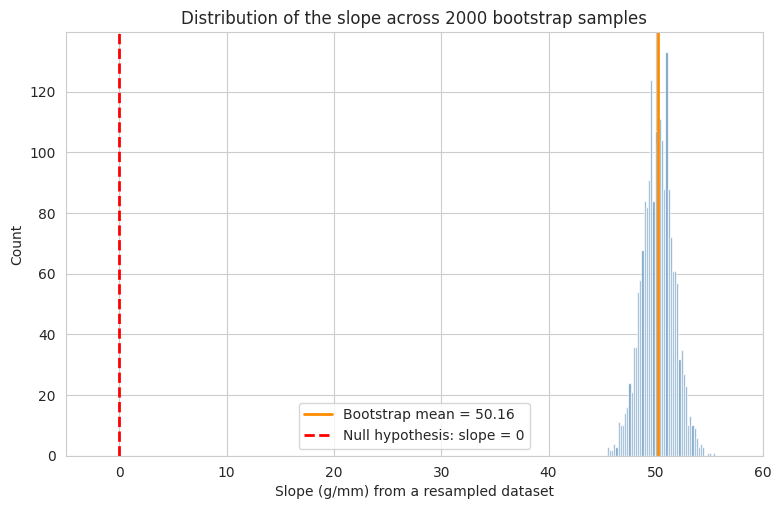

In [3]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.hist(bootstrap_slopes, bins=50, color='steelblue', alpha=0.75, edgecolor='white')
ax.axvline(bootstrap_mean, color='darkorange', linewidth=2,
           label=f'Bootstrap mean = {bootstrap_mean:.2f}')
ax.axvline(0, color='red', linestyle='--', linewidth=2,
           label='Null hypothesis: slope = 0')
ax.set_xlabel('Slope (g/mm) from a resampled dataset')
ax.set_ylabel('Count')
ax.set_title(f'Distribution of the slope across {n_iter} bootstrap samples')
ax.set_xlim(-5, 60)
ax.legend()
plt.show()

Two things to notice in that histogram:

1. **It's roughly bell-shaped and tight**, centered around 50, with most of the mass between about 47 and 53. In 2000 tries, *not a single resample* gave us a slope anywhere close to zero.
2. **The red dashed line — the null hypothesis's slope of 0 — is miles away** from anything the bootstrap produced.

That visual gap is already a very strong clue that $H_0$ is in trouble. Let's make "in trouble" quantitative.

---

## Section 3: The P-Value — Simulating the Null World

The bootstrap told us how much the slope wiggles *in a world where our relationship is real*. The p-value asks the opposite question: **in a world where the relationship is fake ($H_0$ is true), how rare is a slope like ours?**

Statsmodels gives us an answer in the `P>|t|` column: `0.000`. That is, in the null world, a slope this extreme happens less than 1 time in 1000.

But where does that number come from? Just like last section, we don't need the formula — we can simulate the null world directly.

**The trick:** if flipper length truly has no relationship to body mass, then the body masses are essentially just randomly shuffled onto whatever flipper lengths we happen to have. So to simulate $H_0$, we take our actual `y` (body mass) values and **randomly shuffle them**, destroying any real $x$–$y$ relationship while keeping each variable's distribution intact. Then we fit a line to the scrambled data and record the slope. Repeat many times. That's the null distribution of the slope.

In [4]:
n_iter = 5000
null_slopes = np.empty(n_iter)

for i in range(n_iter):
    y_shuffled = rng.permutation(y_arr)        # destroy any real relationship
    null_slopes[i] = np.cov(x_arr, y_shuffled, bias=True)[0, 1] / np.var(x_arr)

observed_slope = model_sm.params['flipper_length_mm']

# The two-sided empirical p-value: fraction of null slopes that are at least as extreme.
p_empirical = np.mean(np.abs(null_slopes) >= np.abs(observed_slope))

print(f'Observed slope:                    {observed_slope:.4f} g/mm')
print(f'Null distribution mean:            {null_slopes.mean():.4f} g/mm  (should be ~0)')
print(f'Null distribution std dev:         {null_slopes.std(ddof=1):.4f} g/mm')
print(f'Empirical p-value (of {n_iter} shuffles): {p_empirical}')
print(f'Statsmodels p-value:               {model_sm.pvalues["flipper_length_mm"]:.3g}')

Observed slope:                    50.1533 g/mm
Null distribution mean:            0.0504 g/mm  (should be ~0)
Null distribution std dev:         3.1823 g/mm
Empirical p-value (of 5000 shuffles): 0.0
Statsmodels p-value:               3.13e-105


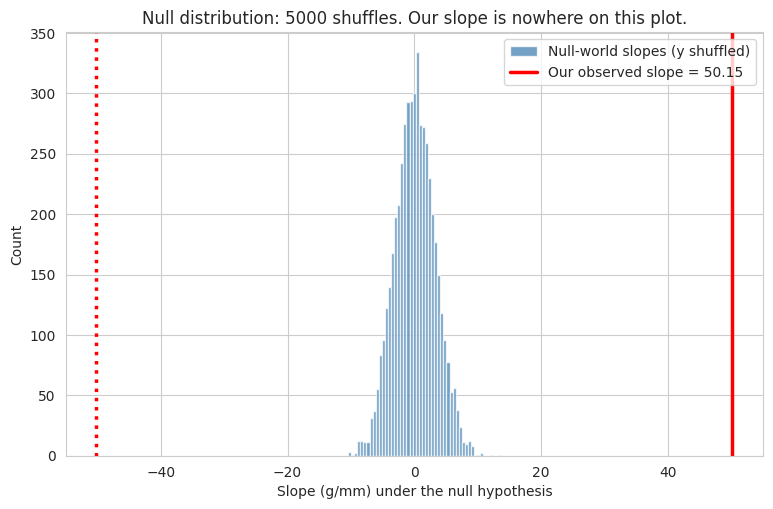

In [5]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.hist(null_slopes, bins=50, color='steelblue', alpha=0.75, edgecolor='white',
        label='Null-world slopes (y shuffled)')
ax.axvline(observed_slope, color='red', linewidth=2.5,
           label=f'Our observed slope = {observed_slope:.2f}')
ax.axvline(-observed_slope, color='red', linewidth=2.5, linestyle=':')
ax.set_xlabel('Slope (g/mm) under the null hypothesis')
ax.set_ylabel('Count')
ax.set_title(f'Null distribution: {n_iter} shuffles. Our slope is nowhere on this plot.')
ax.set_xlim(-55, 55)
ax.legend()
plt.show()

Stare at this plot for a second. That blue hill is **every slope the null world could plausibly produce**. It's centered on zero (exactly as $H_0$ predicts), and it stretches from about −5 to +5. Our actual slope of 50.15 is so far to the right that it doesn't even fit in the frame — the red line is off in another county.

Out of 5000 shuffles of the body masses, **not a single one** produced a slope anywhere near as extreme as ours. So the empirical p-value comes back as **0.0** — meaning < 1 in 5000, which is the resolution limit of our simulation. Statsmodels, using the theoretical t-distribution rather than simulation, pins it down more precisely at about $p \approx 10^{-100}$. Either way, the story is the same:

> **If flipper length had no real relationship with body mass, we would essentially never see a slope of 50 in a sample of 333 penguins. So we reject $H_0$.**

That is what "statistically significant" means. It is not a claim about importance or size or practical relevance. It is a claim about one very specific thing: *the data we observed is extremely unlikely if the null hypothesis were true.*

### The 0.05 convention (and its discontents)

By convention, scientists "reject $H_0$" whenever $p < 0.05$ — the famous 5% threshold. It's the default in papers across biology, psychology, economics, and machine learning.

This is a **convention**, not a law of nature. It was popularized by R.A. Fisher in the 1920s and has been endlessly debated ever since. You should know two things about it:

1. **It is arbitrary.** A p-value of 0.049 and a p-value of 0.051 describe essentially identical evidence, but under the 0.05 convention, one "passes" and the other "fails." Don't treat the threshold as sacred.
2. **A small p-value is not a big effect.** With enough data, a microscopic slope becomes "statistically significant." Always look at the *size* of the coefficient (is a 0.02 g/mm slope biologically meaningful?), not just the p-value.

Our p-value of essentially zero, combined with a slope of 50 g/mm and an $R^2$ of 0.76, is rare luxury: the effect is both highly significant *and* large. Don't expect that combination to show up every time.

---

## Section 4: The 95% Confidence Interval

So we've decisively rejected "the slope is zero." But that leaves an obvious follow-up question:

> **Okay, the slope isn't zero. What *is* it?**

We got 50.15 from *our* sample. If we sampled again we'd get something slightly different. The `std err` told us how much different (about 1.5 g/mm of wiggle). Can we translate that wiggle into a range of plausible values for the true underlying slope?

Yes. That's the **95% confidence interval**, the last two columns of the summary table: `[0.025  0.975]`. For us it reads `[47.124, 53.183]`. Here's where it comes from: we go back to our bootstrap distribution of 2000 slopes, chop off the bottom 2.5% and top 2.5%, and keep the middle 95%.

In [6]:
ci_low, ci_high = np.percentile(bootstrap_slopes, [2.5, 97.5])

sm_ci_low, sm_ci_high = model_sm.conf_int().loc['flipper_length_mm']

print(f'Bootstrap 95% CI:    [{ci_low:.3f}, {ci_high:.3f}]')
print(f'Statsmodels 95% CI:  [{sm_ci_low:.3f}, {sm_ci_high:.3f}]')

Bootstrap 95% CI:    [47.116, 53.115]
Statsmodels 95% CI:  [47.123, 53.183]


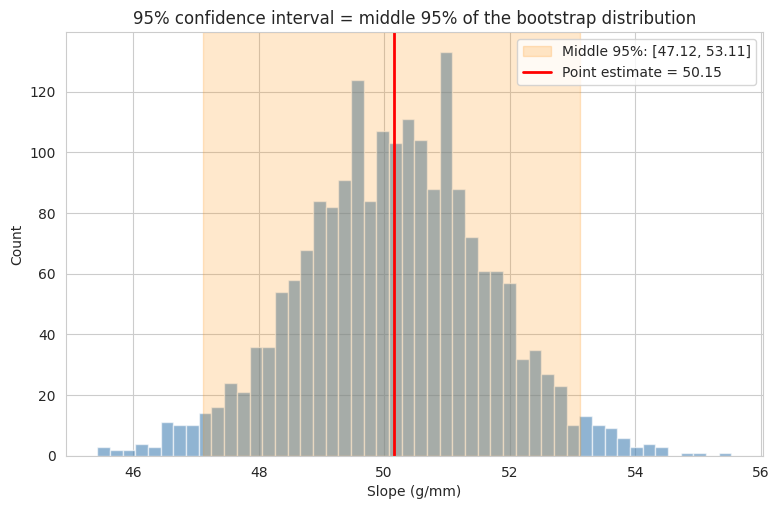

In [7]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.hist(bootstrap_slopes, bins=50, color='steelblue', alpha=0.6, edgecolor='white')
ax.axvspan(ci_low, ci_high, alpha=0.2, color='darkorange',
           label=f'Middle 95%: [{ci_low:.2f}, {ci_high:.2f}]')
ax.axvline(observed_slope, color='red', linewidth=2,
           label=f'Point estimate = {observed_slope:.2f}')
ax.set_xlabel('Slope (g/mm)')
ax.set_ylabel('Count')
ax.set_title('95% confidence interval = middle 95% of the bootstrap distribution')
ax.legend()
plt.show()

The bootstrap CI matches statsmodels's CI to within a hair. Both say roughly the same thing:

> **We don't know the exact "true" slope for all penguins on Earth, but our data is consistent with a true slope somewhere between about 47.1 and 53.2 grams per millimeter.**

### One careful word about interpretation

This is the single most misinterpreted concept in introductory statistics, so let's be precise. A 95% confidence interval does **not** mean *"there's a 95% chance the true slope is between 47.1 and 53.2."* (Under the classical view, the true slope is a fixed unknown number — it's either in that interval or it isn't; there's no probability about it.)

The correct interpretation is a statement about the *procedure*:

> *If we repeated this whole experiment many times — each time sampling 333 penguins and computing a 95% CI — then about 95% of those intervals would contain the true slope.*

This is subtle and a little unsatisfying, but it is what the math actually delivers. In practice, most scientists and data scientists speak looser about CIs ("we're 95% confident the true slope is in that range") and it rarely causes trouble. But when precision matters — in papers, in court, in high-stakes modeling — be exact about what a CI is.

---

## Putting It All Together

We've walked the full length of the middle row of the statsmodels summary table. Here is what each number actually means:

| Column | Our value | What it is |
|---|---|---|
| `coef`       | 50.1533 | The slope our sample gave us. |
| `std err`    | 1.540   | How much the slope would wiggle across hypothetical repeat samples. We simulated this with a **bootstrap**. |
| `t`          | 32.56   | How many standard errors our slope is away from zero. (The engine under the p-value.) |
| `P>\|t\|`    | ~0      | Probability of seeing a slope this extreme if the true slope were zero. We simulated this by **shuffling** $y$. |
| `[0.025  0.975]` | [47.124, 53.183] | Range of true slopes consistent with our data. We simulated this with **percentiles of the bootstrap**. |

And the overall workflow of statistical inference:

> **Fit a line. Compute its slope. Ask "could this plausibly have come from a world where the true slope is zero?" If the answer is no, report the slope with a confidence interval so your reader knows how precise your estimate is.**

### Where We're Going Next

One thing that should bother you by now: *all* of the classical statsmodels output — the `std err`, the p-value, the CI — is computed from formulas that assume certain things about the data. The bootstrap matched those formulas beautifully for our penguins, which suggests the assumptions were satisfied. But what if they weren't?

In `17_1_3_SLR_LINE_Assumptions.ipynb` we're going to meet the four classical assumptions of linear regression — the **LINE** assumptions (Linearity, Independence, Normality of residuals, Equal variance) — and learn how to check them with diagnostic plots. When the assumptions fail, the `std err` and p-value statsmodels prints can be badly wrong, and we'll need to know how to spot it.